# 5b · Cross-dataset transfer evaluation — SENTENCE heads (Type-2)

Companion to notebook 5. Same protocol, but it benchmarks the **deployed Type-2 sentence heads** (`*_sentence_s1*`) in the **sentence regime** (one factual sentence per question) with **LLM-judge labels** (BLEURT is invalid on sentences — the reason the judge exists). Nothing is re-fit on the targets, so every row is held out.

Headline vs nb5 (Type-1 short-QA heads): does per-sentence detection hold across datasets, and is **TSV** still the length-robust head? `FUSED` is a lightweight **3-feature** logreg (TSV-dominant — see the printed weights) fit OOF on the sentence training data; the deployed TSV-only `fusion_claim_s1` is untouched. Saved to `data/<ds>_cross_eval_sentence_s1.parquet` (separate from nb5's files).

In [ ]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
import warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..','tools'))
from cross_eval import evaluate_many
import fit_sentence_fusion
# ---- CONFIG -------------------------------------------------------------------------------
DATASETS = ['squad', 'triviaqa']  # transfer sets (web_questions + nq_open dropped: noisy/stale gold)
TRAIN    = 'triviaqa'                          # heads were trained on this
N        = 20                                 # questions per dataset
OFFSETS  = {'triviaqa': 3000}                  # keep TriviaQA held-out (training used offset 0)
HEAD_SET = 'sentence_s1'                        # Type-2 deployed sentence heads (vs nb5's 'retrained' Type-1)
# ------------------------------------------------------------------------------------------
fit_sentence_fusion.main()                     # (re)fit the 3-feature TSV-dominant eval fusion (CPU, secs)
SCORED = evaluate_many(DATASETS, train_ds=TRAIN, n=N, offsets=OFFSETS, head_set=HEAD_SET)
print('done:', list(SCORED.keys()))

### Per-dataset metrics (AUROC / AUPR / Accuracy / Precision / Recall / F1)

In [2]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
import warnings; warnings.filterwarnings('ignore')
import metrics as M, pandas as pd, numpy as np
DETS = {'SEP':'sep_entropy', 'HalluShift':'hallushift', 'TSV':'tsv_margin', 'FUSED':'fused'}
METRICS = {}
for ds, (_, df) in SCORED.items():
    y = df['hallucination'].to_numpy()
    res = {}
    for name, col in DETS.items():
        s = df[col].to_numpy()
        m = M.detector_metrics(y, s, threshold=M.best_threshold(y, s))
        M.attach_curves(m, y, s)
        res[name] = m
    METRICS[ds] = res
    print(f'\n=== {ds}  (n={len(df)}, halluc={y.mean()*100:.1f}%) ===')
    print(M.summary_table(res).to_string())


=== squad  (n=19, halluc=21.1%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.9000  0.7857    0.8421     0.5714     1.0  0.7273
HalluShift  0.7333  0.4702    0.8421     0.6667     0.5  0.5714
TSV         0.9833  0.9500    0.9474     0.8000     1.0  0.8889
FUSED       0.9833  0.9500    0.9474     0.8000     1.0  0.8889

=== triviaqa  (n=20, halluc=30.0%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.7619  0.6601      0.65     0.4615  1.0000  0.6316
HalluShift  0.3333  0.2606      0.30     0.3000  1.0000  0.4615
TSV         0.7500  0.6188      0.70     0.5000  0.8333  0.6250
FUSED       0.7500  0.5161      0.80     0.6250  0.8333  0.7143


### ROC / PR curves + confusion matrices per dataset

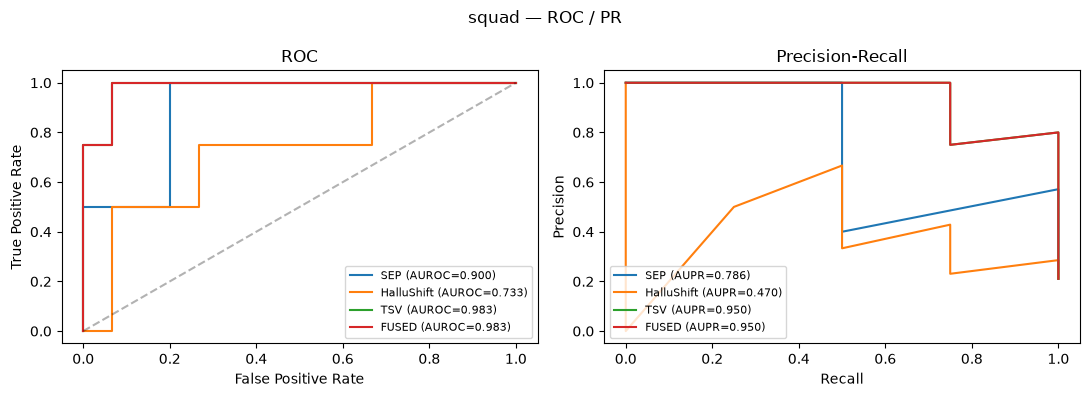

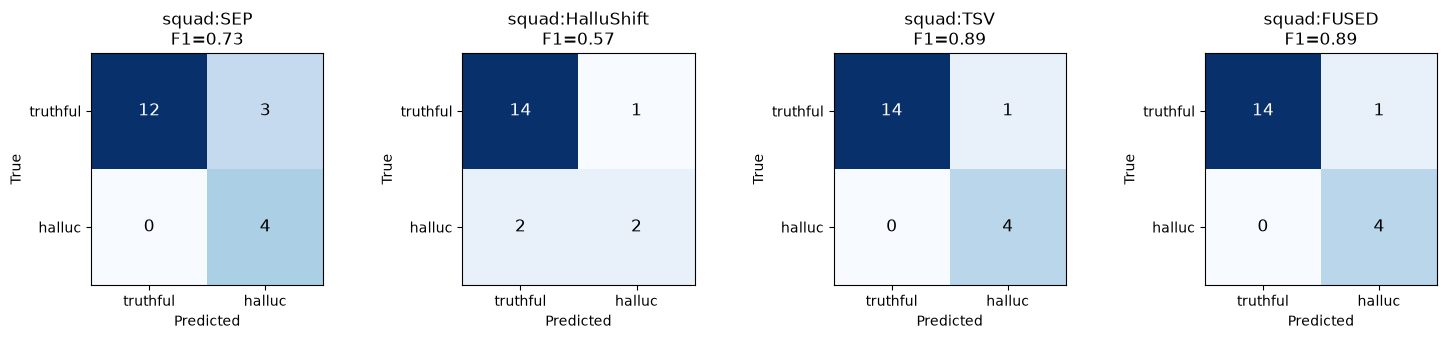

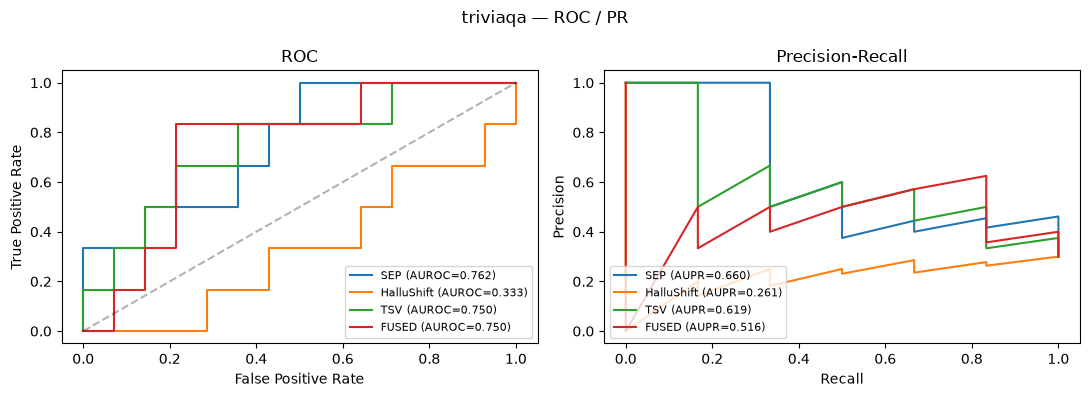

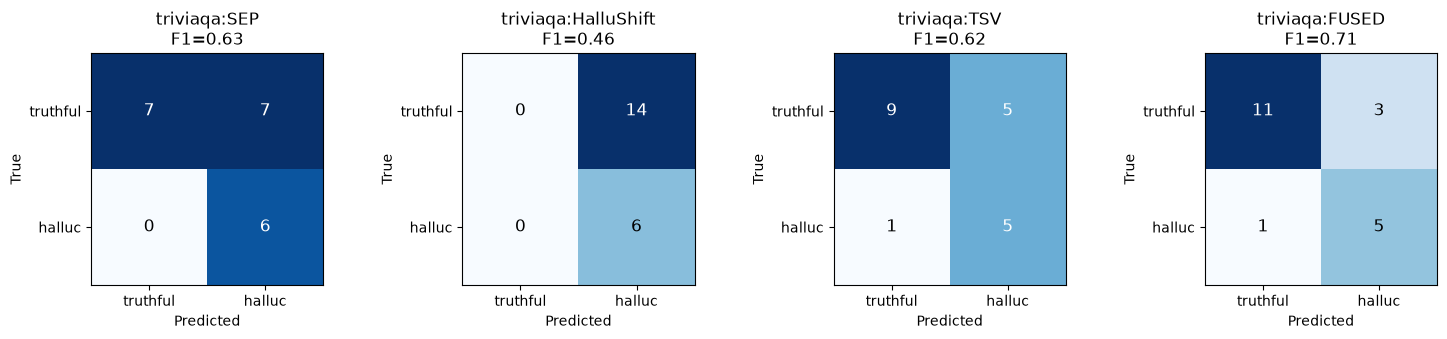

In [3]:
import matplotlib.pyplot as plt
for ds, res in METRICS.items():
    fig, ax = plt.subplots(1, 2, figsize=(11,4))
    M.plot_roc(ax[0], res); M.plot_pr(ax[1], res)
    fig.suptitle(f'{ds} — ROC / PR'); plt.tight_layout(); plt.show()
    fig, axes = plt.subplots(1, 4, figsize=(15,3.4))
    for axx,(name,m) in zip(axes, res.items()):
        M.plot_confusion(axx, m['confusion_matrix'], title=f"{ds}:{name}\nF1={m['F1']:.2f}")
    plt.tight_layout(); plt.show()

### Headline — does FUSED stay on top across datasets?

Pivot tables (rows = dataset, cols = detector). Watch the **best single detector change** between rows while **FUSED stays ≥ the best single** — that is the robustness story.

In [4]:
for metric in ['AUROC','AUPR','F1']:
    piv = pd.DataFrame({ds:{name:res[name][metric] for name in DETS}
                        for ds,res in METRICS.items()}).T.round(3)
    piv['best_single'] = piv[['SEP','HalluShift','TSV']].idxmax(axis=1)
    piv['FUSED_wins'] = piv['FUSED'] >= piv[['SEP','HalluShift','TSV']].max(axis=1)
    print(f'\n=== {metric} (rows=dataset, cols=detector) ===')
    print(piv.to_string())


=== AUROC (rows=dataset, cols=detector) ===
            SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
squad     0.900       0.733  0.983  0.983         TSV        True
triviaqa  0.762       0.333  0.750  0.750         SEP       False

=== AUPR (rows=dataset, cols=detector) ===
            SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
squad     0.786       0.470  0.950  0.950         TSV        True
triviaqa  0.660       0.261  0.619  0.516         SEP       False

=== F1 (rows=dataset, cols=detector) ===
            SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
squad     0.727       0.571  0.889  0.889         TSV        True
triviaqa  0.632       0.462  0.625  0.714         SEP        True
